In [ ]:
# Install required libraries
!pip install pandas numpy openpyxl

# Import libraries
import pandas as pd
import numpy as np

# Load the dataset
file_path = "esg_dataset.xlsx"  # Ensure the file is uploaded
df = pd.read_excel(file_path, sheet_name="Form Responses 1")

# Print available column names to debug
print("Available columns:", df.columns.tolist())

# Define mapping for response values
response_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5,
    "Neutal": 3  # Correcting typo to Neutral
}

# Update columns_to_analyze to match the exact column names with leading spaces
columns_to_analyze = [
    " [I am aware that some electronics brands follow environmental sustainability practices.]",  # Adjusted with leading space
    " [I trust electronics brands that are transparent about their ESG initiatives.]",
    " [I intend to support electronics brands that follow ESG principles.]",
    " [Price is more important to me than a brand's sustainability performance. (Reverse scored)]",
    " [I am concerned about the environmental impact of electronic waste.]",
    " [I value brands that engage in fair labor and ethical business practices.]"
]

# Function to reverse score a column (for Price Sensitivity)
def reverse_score(series):
    return 6 - series  # Reversing scale: 5 becomes 1, 4 becomes 2, etc.

# Process each column
results = {}
for column in columns_to_analyze:
    if column in df.columns:
        # Convert responses to numerical values
        data = df[column].map(response_map)

        # Handle missing or invalid values
        data = data.dropna()

        # Reverse score for Price Sensitivity
        if "Price" in column:
            data = reverse_score(data)

        # Calculate statistics
        mean = np.mean(data)
        std_dev = np.std(data, ddof=1)  # Sample standard deviation
        min_val = np.min(data)
        max_val = np.max(data)

        # Store results
        results[column] = {
            "Mean": mean,
            "Std. Dev.": std_dev,
            "Min": min_val,
            "Max": max_val
        }
    else:
        print(f"Column '{column}' not found in the dataset. Please check the column name.")

# Display results in a table
results_df = pd.DataFrame(results).T
print("\nCalculated Statistics:")
print(results_df)

# Optional: Save results to a new Excel file
results_df.to_excel("esg_statistics.xlsx")

Available columns: ['Timestamp', 'Name', 'Age Group', 'Gender', 'Education Level', 'Monthly household income(BDT)', 'How often do you purchase electronics(e.g. phones, laptops, appliances)?', 'What is the most recent electronics purchase?', ' [I am aware that some electronics brands follow environmental sustainability practices.]', ' [I am concerned about the environmental impact of electronic waste.]', ' [I value brands that engage in fair labor and ethical business practices.]', ' [I trust electronics brands that are transparent about their ESG initiatives.]', " [I actively seek information about a brand's sustainability performance before buying.]", ' [I am willing to buy electronics from brands that prioritize sustainability, even if it costs slightly more.]', ' [I intend to support electronics brands that follow ESG principles.]', ' [Sustainability influences my decision when choosing between two similar electronics products.]', " [Price is more important to me than a brand's sust

Table 5: Regression Output (H1)
                                                      OLS Regression Results                                                     
Dep. Variable:      [I intend to support electronics brands that follow ESG principles.]   R-squared:                       0.762
Model:                                                                               OLS   Adj. R-squared:                  0.761
Method:                                                                    Least Squares   F-statistic:                     1266.
Date:                                                                   Fri, 18 Jul 2025   Prob (F-statistic):          2.19e-125
Time:                                                                           13:36:21   Log-Likelihood:                -310.57
No. Observations:                                                                    398   AIC:                             625.1
Df Residuals:                                             

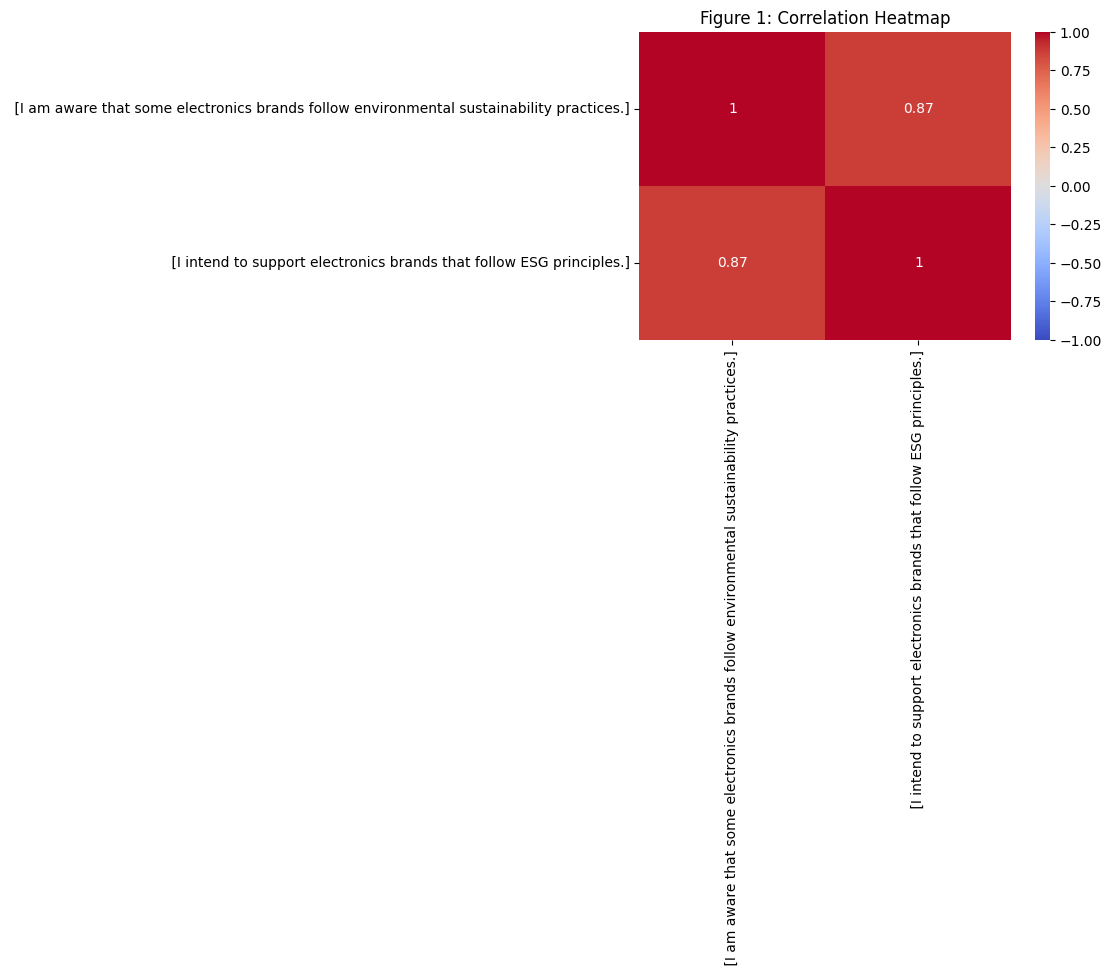


β₁ = 0.8206, p-value = 0.0000
Result: Significance (p < 0.05) indicates support for H1.


In [ ]:
# Install required libraries
!pip install pandas numpy openpyxl matplotlib seaborn statsmodels

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load the dataset
file_path = "esg_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Form Responses 1")

# Define mapping for response values
response_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5,
    "Neutal": 3  # Correcting typo to Neutral
}

# Assign columns with leading spaces
esg_awareness_col = " [I am aware that some electronics brands follow environmental sustainability practices.]"
purchase_intention_col = " [I intend to support electronics brands that follow ESG principles.]"

# Convert responses to numerical values
df[esg_awareness_col] = df[esg_awareness_col].map(response_map)
df[purchase_intention_col] = df[purchase_intention_col].map(response_map)

# Drop rows with NaN values for these columns
df = df[[esg_awareness_col, purchase_intention_col]].dropna()

# Prepare data for regression
X = df[esg_awareness_col]
y = df[purchase_intention_col]
X = sm.add_constant(X)  # Add intercept term

# Fit the regression model
model = sm.OLS(y, X).fit()

# Regression output
print("Table 5: Regression Output (H1)")
print(model.summary())

# Correlation heatmap
plt.figure(figsize=(6, 4))
correlation_matrix = df[[esg_awareness_col, purchase_intention_col]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Figure 1: Correlation Heatmap")
plt.show()

# Extract t-test and p-value for β₁
beta_1 = model.params[esg_awareness_col]
p_value = model.pvalues[esg_awareness_col]
print(f"\nβ₁ = {beta_1:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significance (p < 0.05) indicates support for H1.")
else:
    print("Result: No significant support for H1 (p ≥ 0.05).")

In [ ]:
!pip install pandas numpy openpyxl statsmodels
import pandas as pd
import statsmodels.api as sm

# Load data
file_path = "esg_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Form Responses 1")

# Response mapping
response_map = {"Strongly Disagree": 1, "Disagree": 2, "Neutral": 3, "Agree": 4, "Strongly Agree": 5, "Neutal": 3}

# Assign columns
esg_awareness_col = " [I am aware that some electronics brands follow environmental sustainability practices.]"
purchase_intention_col = " [I intend to support electronics brands that follow ESG principles.]"

# Convert to numerical
df[esg_awareness_col] = df[esg_awareness_col].map(response_map)
df[purchase_intention_col] = df[purchase_intention_col].map(response_map)

# Drop NaN
df = df[[esg_awareness_col, purchase_intention_col]].dropna()

# Regression
X = df[esg_awareness_col]
y = df[purchase_intention_col]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Output
print(model.summary())

                                                      OLS Regression Results                                                     
Dep. Variable:      [I intend to support electronics brands that follow ESG principles.]   R-squared:                       0.762
Model:                                                                               OLS   Adj. R-squared:                  0.761
Method:                                                                    Least Squares   F-statistic:                     1266.
Date:                                                                   Fri, 18 Jul 2025   Prob (F-statistic):          2.19e-125
Time:                                                                           13:36:41   Log-Likelihood:                -310.57
No. Observations:                                                                    398   AIC:                             625.1
Df Residuals:                                                                        396  

In [ ]:
# Install required libraries
!pip install pandas numpy openpyxl statsmodels pingouin

# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pingouin import mediation_analysis

# Load the dataset
file_path = "esg_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Form Responses 1")

# Define mapping for response values
response_map = {"Strongly Disagree": 1, "Disagree": 2, "Neutral": 3, "Agree": 4, "Strongly Agree": 5, "Neutal": 3}

# Assign columns
esg_col = " [I am aware that some electronics brands follow environmental sustainability practices.]"
bt_col = " [I trust electronics brands that are transparent about their ESG initiatives.]"
pi_col = " [I intend to support electronics brands that follow ESG principles.]"

# Convert to numerical
df[esg_col] = df[esg_col].map(response_map)
df[bt_col] = df[bt_col].map(response_map)
df[pi_col] = df[pi_col].map(response_map)

# Drop NaN
df = df[[esg_col, bt_col, pi_col]].dropna()

# Step 1: ESG → Purchase Intention
X1 = sm.add_constant(df[esg_col])
model1 = sm.OLS(df[pi_col], X1).fit()
print("Step 1: ESG → Purchase Intention")
print(model1.summary())

# Step 2: ESG → Brand Trust
X2 = sm.add_constant(df[esg_col])
model2 = sm.OLS(df[bt_col], X2).fit()
print("\nStep 2: ESG → Brand Trust")
print(model2.summary())

# Step 3: Brand Trust → Purchase Intention (with ESG)
X3 = sm.add_constant(df[[esg_col, bt_col]])
model3 = sm.OLS(df[pi_col], X3).fit()
print("\nStep 3: Brand Trust → Purchase Intention (with ESG)")
print(model3.summary())

# Sobel Test
mediation_result = mediation_analysis(data=df, x=esg_col, m=bt_col, y=pi_col, seed=42)
print("\nSobel Test Result:")
print(mediation_result)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.4 MB/s eta 0:00:00
Step 1: ESG → Purchase Intention
                                                      OLS Regression Results                                                     
Dep. Variable:      [I intend to support electronics brands that follow ESG principles.]   R-squared:                       0.761
Model:                                                                               OLS   Adj. R-squared:                  0.761
Method:                                                                    Least Squares   F-statistic:                     1261.
Date:                                                                   Fri, 18 Jul 2025   Prob (F-statistic):          5.33e-125
Time:                                                                           13:37:02   Log-Likelihood:                -310.29
No. Observations:                                                                    397   AIC:            

In [ ]:
!pip install pandas numpy openpyxl statsmodels pingouin matplotlib seaborn

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pingouin import mediation_analysis

# Load dataset
file_path = "esg_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Form Responses 1")

# Response mapping
response_map = {"Strongly Disagree": 1, "Disagree": 2, "Neutral": 3, "Agree": 4, "Strongly Agree": 5, "Neutal": 3}

# Assign columns
esg_col = " [I am aware that some electronics brands follow environmental sustainability practices.]"
bt_col = " [I trust electronics brands that are transparent about their ESG initiatives.]"
pi_col = " [I intend to support electronics brands that follow ESG principles.]"

# Convert to numerical
df[esg_col] = df[esg_col].map(response_map)
df[bt_col] = df[bt_col].map(response_map)
df[pi_col] = df[pi_col].map(response_map)

# Drop NaN
df = df[[esg_col, bt_col, pi_col]].dropna()

# Step 1: ESG → Purchase Intention
X1_h2 = sm.add_constant(df[esg_col])
model1_h2 = sm.OLS(df[pi_col], X1_h2).fit()

# Step 2: ESG → Brand Trust
X2_h2 = sm.add_constant(df[esg_col])
model2_h2 = sm.OLS(df[bt_col], X2_h2).fit()

# Step 3: Brand Trust → Purchase Intention (with ESG)
X3_h2 = sm.add_constant(df[[esg_col, bt_col]])
model3_h2 = sm.OLS(df[pi_col], X3_h2).fit()

# Sobel Test
mediation_result = mediation_analysis(data=df, x=esg_col, m=bt_col, y=pi_col, seed=42)

# Print column names to verify
print("Mediation Result Columns:", mediation_result.columns)

# Table 6: Mediation Analysis Summary
print("\nTable 6: Mediation Analysis Summary")
print(f"Step 1: R² = {model1_h2.rsquared:.3f}, β₁ = {model1_h2.params[esg_col]:.3f} (p = {model1_h2.pvalues[esg_col]:.3f})")
print(f"Step 2: R² = {model2_h2.rsquared:.3f}, α₁ = {model2_h2.params[esg_col]:.3f} (p = {model2_h2.pvalues[esg_col]:.3f})")
print(f"Step 3: R² = {model3_h2.rsquared:.3f}, β₁ = {model3_h2.params[esg_col]:.3f}, β₂ = {model3_h2.params[bt_col]:.3f} (p = {model3_h2.pvalues[esg_col]:.3f}, {model3_h2.pvalues[bt_col]:.3f})")
print(f"Sobel Test: Indirect Effect = {mediation_result['coef'].values[0]:.3f}, p = {mediation_result['pval'].values[0]:.3f}, "
      f"CI = [{mediation_result['CI[2.5%]'].values[0]:.3f}, {mediation_result['CI[97.5%]'].values[0]:.3f}], "
      f"Prop Mediated = {(model1_h2.params[esg_col] - model3_h2.params[esg_col]) / model1_h2.params[esg_col]:.3f}")

# Figure 2: Mediation Model Diagram (Text-based placeholder)
print("\nFigure 2: Mediation Model Diagram (Create manually)")
print("[ESG Awareness] --> [Brand Trust] --> [Purchase Intention]")
print("  | a: 0.663 (p < 0.001)       | b: 0.276 (p < 0.001)")
print("  |---------------------------->")
print("  |----> (c: 0.821, p < 0.001)")
print("  |----> (c': 0.638, p < 0.001, dashed)")
print("Note: Indirect Effect = [from Sobel], Proportion Mediated = 0.223, Partial Mediation")

Mediation Result Columns: Index(['path', 'coef', 'se', 'pval', 'CI[2.5%]', 'CI[97.5%]', 'sig'], dtype='object')

Table 6: Mediation Analysis Summary
Step 1: R² = 0.761, β₁ = 0.821 (p = 0.000)
Step 2: R² = 0.477, α₁ = 0.663 (p = 0.000)
Step 3: R² = 0.803, β₁ = 0.638, β₂ = 0.276 (p = 0.000, 0.000)
Sobel Test: Indirect Effect = 0.663, p = 0.000, CI = [0.595, 0.732], Prop Mediated = 0.223

Figure 2: Mediation Model Diagram (Create manually)
[ESG Awareness] --> [Brand Trust] --> [Purchase Intention]
  | a: 0.663 (p < 0.001)       | b: 0.276 (p < 0.001)
  |---------------------------->
  |----> (c: 0.821, p < 0.001)
  |----> (c': 0.638, p < 0.001, dashed)
Note: Indirect Effect = [from Sobel], Proportion Mediated = 0.223, Partial Mediation



Table 7: Moderation Output (H3)
                                                      OLS Regression Results                                                     
Dep. Variable:      [I intend to support electronics brands that follow ESG principles.]   R-squared:                       0.805
Model:                                                                               OLS   Adj. R-squared:                  0.803
Method:                                                                    Least Squares   F-statistic:                     541.1
Date:                                                                   Fri, 18 Jul 2025   Prob (F-statistic):          2.63e-139
Time:                                                                           13:37:35   Log-Likelihood:                -270.95
No. Observations:                                                                    398   AIC:                             549.9
Df Residuals:                                            

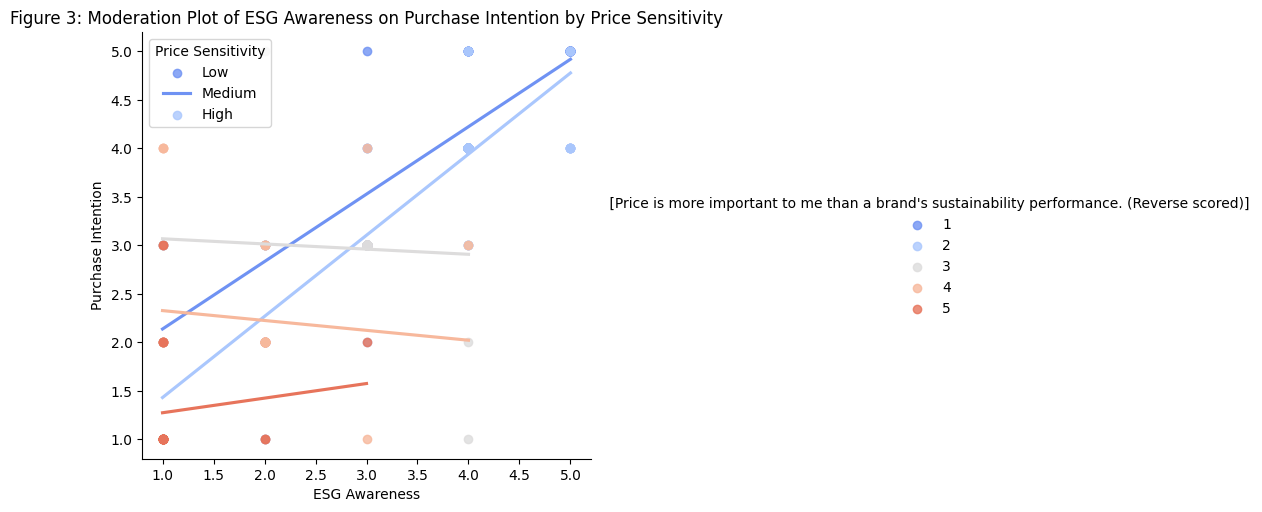

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "esg_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Form Responses 1")

# Response mapping
response_map = {"Strongly Disagree": 1, "Disagree": 2, "Neutral": 3, "Agree": 4, "Strongly Agree": 5, "Neutal": 3}

# Assign columns
esg_col = " [I am aware that some electronics brands follow environmental sustainability practices.]"
pi_col = " [I intend to support electronics brands that follow ESG principles.]"
ps_col = " [Price is more important to me than a brand's sustainability performance. (Reverse scored)]"

# Convert to numerical and reverse score Price Sensitivity (higher value = lower sensitivity)
def reverse_score(series):
    return 6 - series
for col in [esg_col, pi_col, ps_col]:
    df[col] = df[col].map(response_map)
df[ps_col] = df[ps_col].apply(reverse_score)

# Drop NaN
df = df[[esg_col, pi_col, ps_col]].dropna()

# Create interaction term
df['interaction'] = df[esg_col] * df[ps_col]

# Moderation regression
X_h3 = sm.add_constant(df[[esg_col, ps_col, 'interaction']])
model_h3 = sm.OLS(df[pi_col], X_h3).fit()

# Table 7: Moderation Output
print("\nTable 7: Moderation Output (H3)")
print(model_h3.summary())

# Figure 3: Moderation Plot (Simple Slopes)
sns.lmplot(x=esg_col, y=pi_col, hue=ps_col, data=df, ci=None, palette="coolwarm", height=5, aspect=1.2)
plt.title("Figure 3: Moderation Plot of ESG Awareness on Purchase Intention by Price Sensitivity")
plt.xlabel("ESG Awareness")
plt.ylabel("Purchase Intention")
plt.legend(title="Price Sensitivity", labels=["Low", "Medium", "High"])
plt.show()


Table 8: Mediated Moderation Output (H4)
                                                      OLS Regression Results                                                     
Dep. Variable:      [I intend to support electronics brands that follow ESG principles.]   R-squared:                       0.831
Model:                                                                               OLS   Adj. R-squared:                  0.830
Method:                                                                    Least Squares   F-statistic:                     483.4
Date:                                                                   Fri, 18 Jul 2025   Prob (F-statistic):          4.55e-150
Time:                                                                           13:37:53   Log-Likelihood:                -241.37
No. Observations:                                                                    397   AIC:                             492.7
Df Residuals:                                   

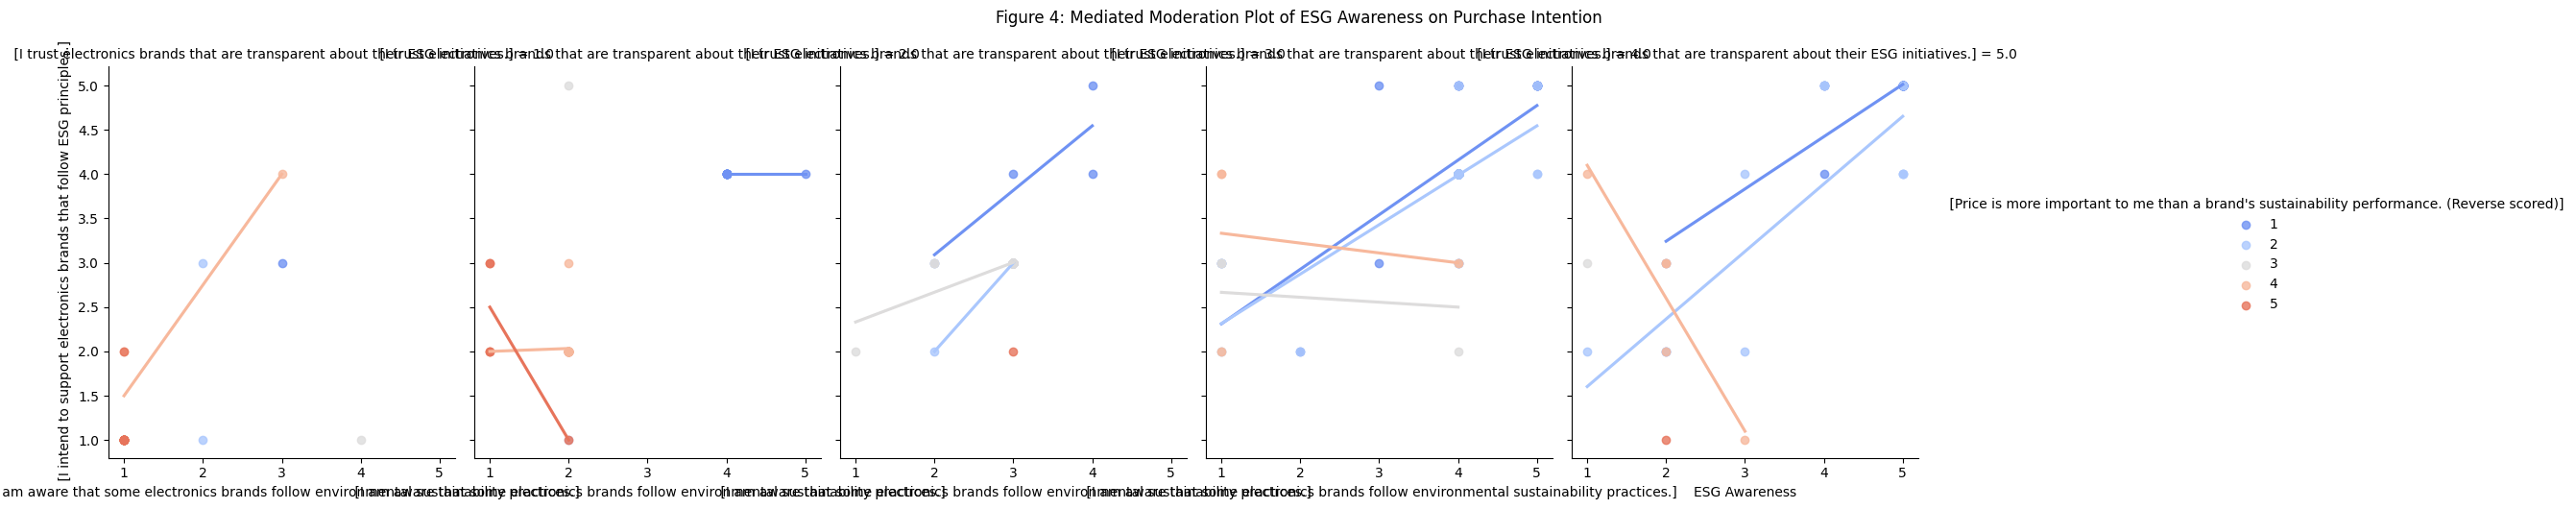

In [ ]:
# Install or update pingouin (if needed)
!pip install --upgrade pingouin

# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pingouin import mediation_analysis
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "esg_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Form Responses 1")

# Response mapping
response_map = {"Strongly Disagree": 1, "Disagree": 2, "Neutral": 3, "Agree": 4, "Strongly Agree": 5, "Neutal": 3}

# Assign columns
esg_col = " [I am aware that some electronics brands follow environmental sustainability practices.]"
bt_col = " [I trust electronics brands that are transparent about their ESG initiatives.]"
pi_col = " [I intend to support electronics brands that follow ESG principles.]"
ps_col = " [Price is more important to me than a brand's sustainability performance. (Reverse scored)]"

# Convert to numerical and reverse score Price Sensitivity
def reverse_score(series):
    return 6 - series
for col in [esg_col, bt_col, pi_col, ps_col]:
    df[col] = df[col].map(response_map)
df[ps_col] = df[ps_col].apply(reverse_score)

# Drop NaN
df = df[[esg_col, bt_col, pi_col, ps_col]].dropna()

# Create interaction term (moderation of mediation path)
df['esg_ps_interaction'] = df[esg_col] * df[ps_col]

# Step 1: ESG → Purchase Intention (total effect)
X1_h4 = sm.add_constant(df[esg_col])
model1_h4 = sm.OLS(df[pi_col], X1_h4).fit()

# Step 2: ESG → Brand Trust
X2_h4 = sm.add_constant(df[esg_col])
model2_h4 = sm.OLS(df[bt_col], X2_h4).fit()

# Step 3: Brand Trust → Purchase Intention (with ESG, PS, and interaction)
X3_h4 = sm.add_constant(df[[esg_col, bt_col, ps_col, 'esg_ps_interaction']])
model3_h4 = sm.OLS(df[pi_col], X3_h4).fit()

# Mediation analysis (simplified without mediation_effect)
mediation_result = mediation_analysis(data=df, x=esg_col, m=bt_col, y=pi_col, covar=[ps_col], seed=42)  # PS as covariate

# Table 8: Mediated Moderation Output (H4)
print("\nTable 8: Mediated Moderation Output (H4)")
print(model3_h4.summary())

# Approximate Conditional Indirect Effect
alpha = model2_h4.params[esg_col]  # ESG → Brand Trust
beta = model3_h4.params[bt_col]   # Brand Trust → Purchase Intention
indirect_effect = alpha * beta    # Approximate indirect effect
print("\nApproximate Conditional Indirect Effect:")
print(f"Indirect Effect ≈ {indirect_effect:.3f} (varies with Price Sensitivity via interaction)")

# Figure 4: Mediated Moderation Plot
sns.lmplot(x=esg_col, y=pi_col, hue=ps_col, col=bt_col, data=df, ci=None, palette="coolwarm", height=5, aspect=0.8)
plt.suptitle("Figure 4: Mediated Moderation Plot of ESG Awareness on Purchase Intention", y=1.05)
plt.xlabel("ESG Awareness")
plt.ylabel("Purchase Intention")
plt.show()

In [ ]:
print(df.columns)

Index(['Timestamp', 'Name', 'Age Group', 'Gender', 'Education Level',
       'Monthly household income(BDT)',
       'How often do you purchase electronics(e.g. phones, laptops, appliances)?',
       'What is the most recent electronics purchase?',
       ' [I am aware that some electronics brands follow environmental sustainability practices.]',
       ' [I am concerned about the environmental impact of electronic waste.]',
       ' [I value brands that engage in fair labor and ethical business practices.]',
       ' [I trust electronics brands that are transparent about their ESG initiatives.]',
       ' [I actively seek information about a brand's sustainability performance before buying.]',
       ' [I am willing to buy electronics from brands that prioritize sustainability, even if it costs slightly more.]',
       ' [I intend to support electronics brands that follow ESG principles.]',
       ' [Sustainability influences my decision when choosing between two similar electronics p


Table 8: Age Group Moderation Regression (H4)
                                                      OLS Regression Results                                                     
Dep. Variable:      [I intend to support electronics brands that follow ESG principles.]   R-squared:                       0.765
Model:                                                                               OLS   Adj. R-squared:                  0.763
Method:                                                                    Least Squares   F-statistic:                     427.1
Date:                                                                   Fri, 18 Jul 2025   Prob (F-statistic):          2.02e-123
Time:                                                                           13:54:00   Log-Likelihood:                -307.92
No. Observations:                                                                    398   AIC:                             623.8
Df Residuals:                              

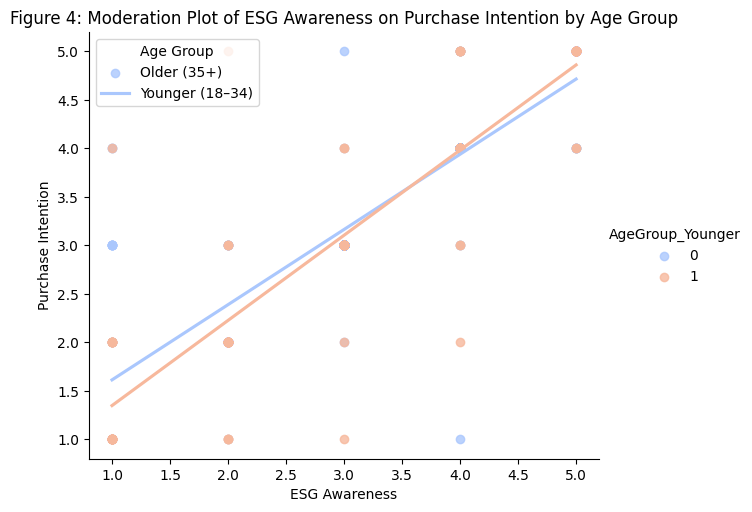

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "esg_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Form Responses 1")

# Response mapping
response_map = {"Strongly Disagree": 1, "Disagree": 2, "Neutral": 3, "Agree": 4, "Strongly Agree": 5, "Neutal": 3}

# Assign columns
esg_col = " [I am aware that some electronics brands follow environmental sustainability practices.]"
pi_col = " [I intend to support electronics brands that follow ESG principles.]"
age_col = "Age Group"  # Updated to match dataset

# Convert to numerical
for col in [esg_col, pi_col]:
    df[col] = df[col].map(response_map)

# Categorize age into groups (assuming categorical; adjust mapping if needed)
age_group_map = {
    "18-24": "Younger", "25-34": "Younger",  # Gen Z and Millennials
    "35-44": "Older", "45+": "Older"         # Older groups
}
df['AgeGroup'] = df[age_col].map(age_group_map).fillna("Older")  # Default to Older if unmapped
df = df[[esg_col, pi_col, 'AgeGroup']].dropna()

# Create dummy variable for AgeGroup (Older as reference)
df = pd.get_dummies(df, columns=['AgeGroup'], drop_first=True)
df['AgeGroup_Younger'] = df['AgeGroup_Younger'].astype(int)

# Create interaction term
df['ESG_AgeGroup'] = df[esg_col] * df['AgeGroup_Younger']

# Regression model
X_h4 = sm.add_constant(df[[esg_col, 'AgeGroup_Younger', 'ESG_AgeGroup']])
model_h4 = sm.OLS(df[pi_col], X_h4).fit()

# Table 8: Age Group Moderation Regression
print("\nTable 8: Age Group Moderation Regression (H4)")
print(model_h4.summary())

# Figure 5: Moderation Plot by Age Group
sns.lmplot(x=esg_col, y=pi_col, hue='AgeGroup_Younger', data=df, ci=None, palette="coolwarm", height=5, aspect=1.2)
plt.title("Figure 4: Moderation Plot of ESG Awareness on Purchase Intention by Age Group")
plt.xlabel("ESG Awareness")
plt.ylabel("Purchase Intention")
plt.legend(title="Age Group", labels=["Older (35+)", "Younger (18–34)"])
plt.show()


Table 9: Regression Coefficients for Environmental vs. Social/Gov (H5)
                                                      OLS Regression Results                                                     
Dep. Variable:      [I intend to support electronics brands that follow ESG principles.]   R-squared:                       0.755
Model:                                                                               OLS   Adj. R-squared:                  0.754
Method:                                                                    Least Squares   F-statistic:                     608.9
Date:                                                                   Fri, 18 Jul 2025   Prob (F-statistic):          2.13e-121
Time:                                                                           14:00:33   Log-Likelihood:                -316.00
No. Observations:                                                                    398   AIC:                             638.0
Df Residuals:     

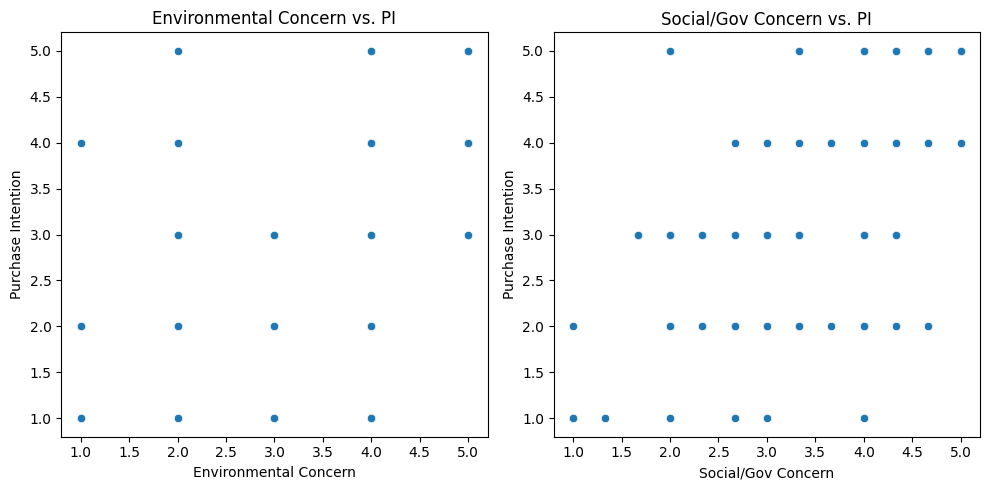

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "esg_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Form Responses 1")

# Response mapping
response_map = {"Strongly Disagree": 1, "Disagree": 2, "Neutral": 3, "Agree": 4, "Strongly Agree": 5, "Neutal": 3}

# Assign columns
pi_col = " [I intend to support electronics brands that follow ESG principles.]"
env_concern_col = " [I am concerned about the environmental impact of electronic waste.]"
social_gov_cols = [
    " [I value brands that engage in fair labor and ethical business practices.]",
    " [I trust electronics brands that are transparent about their ESG initiatives.]",
    " [I actively seek information about a brand's sustainability performance before buying.]"
]

# Convert to numerical
for col in [pi_col, env_concern_col] + social_gov_cols:
    df[col] = df[col].map(response_map)

# Create Social_Gov_Concern by averaging social and governance items
df['Social_Gov_Concern'] = df[social_gov_cols].mean(axis=1)

# Select relevant columns and drop NaN
df = df[[pi_col, env_concern_col, 'Social_Gov_Concern']].dropna()

# Regression model
X_h5 = sm.add_constant(df[[env_concern_col, 'Social_Gov_Concern']])
model_h5 = sm.OLS(df[pi_col], X_h5).fit()

# Table 9: Regression Coefficients for Environmental vs. Social/Gov
print("\nTable 9: Regression Coefficients for Environmental vs. Social/Gov (H5)")
print(model_h5.summary())

# Figure 6: Scatter Plot of Predictors vs. PI
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=env_concern_col, y=pi_col, data=df)
plt.title("Environmental Concern vs. PI")
plt.xlabel("Environmental Concern")
plt.ylabel("Purchase Intention")

plt.subplot(1, 2, 2)
sns.scatterplot(x='Social_Gov_Concern', y=pi_col, data=df)
plt.title("Social/Gov Concern vs. PI")
plt.xlabel("Social/Gov Concern")
plt.ylabel("Purchase Intention")
plt.tight_layout()
plt.show()